In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

loading the required libraries 

In [1]:
!pip install timm -q # Quiet install of the transformer library

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
import cv2
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


medical image preprocessing ()

In [2]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)
        # Apply CLAHE to the L channel in LAB color space (standard for color MRIs)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        cl = self.clahe.apply(l)
        limg = cv2.merge((cl, a, b))
        final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
        return final_img

# Transformation pipeline for Transformers
data_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

loading the data set and the class weights 

In [8]:
import os
import kagglehub
# Download latest version

path = kagglehub.dataset_download("ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes")


print(f"Dataset downloaded to: {path}")


# List the main folders (usually Train, Val, Test)

subfolders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]

print(f"Main Subfolders: {subfolders}")


# Let's peek into the 'Train' folder to see the classes

train_path = os.path.join(path, "Train")

classes = [c for c in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, c))]

print(f"Detected Tumor Classes: {classes}") 

Dataset downloaded to: /kaggle/input/datasets/ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes
Main Subfolders: ['Val', 'Train']
Detected Tumor Classes: ['Pituitary', 'No Tumor', 'Meningioma', 'Glioma']


In [9]:
# Assuming 'path' is already defined from your kagglehub download
train_dir = os.path.join(path, "Train")
val_dir = os.path.join(path, "Val")

train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms)

# --- HANDLING CLASS IMBALANCE ---
# We use WeightedLoss to ensure the model doesn't ignore the smaller classes
targets = train_dataset.targets
class_counts = [targets.count(i) for i in range(len(train_dataset.classes))]
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
weights_tensor = (weights / weights.min()).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"✅ Training images: {len(train_dataset)}")
print(f"✅ Validation images: {len(val_dataset)}")
print(f"⚖️ Calculated Class Weights: {weights_tensor}")

✅ Training images: 4737
✅ Validation images: 512
⚖️ Calculated Class Weights: tensor([1.2567, 1.0000, 2.0380, 1.0176], device='cuda:0')


data set health check

In [10]:
def check_distribution(dataset, name="Dataset"):
    # Get the class names and targets
    classes = dataset.classes
    targets = dataset.targets
    
    print(f"--- {name} Distribution ---")
    counts = {}
    for i, class_name in enumerate(classes):
        count = targets.count(i)
        counts[class_name] = count
        print(f"{class_name}: {count} images")
    return counts

train_counts = check_distribution(train_dataset, "Training")
val_counts = check_distribution(val_dataset, "Validation")


--- Training Distribution ---
Glioma: 1153 images
Meningioma: 1449 images
No Tumor: 711 images
Pituitary: 1424 images
--- Validation Distribution ---
Glioma: 136 images
Meningioma: 140 images
No Tumor: 100 images
Pituitary: 136 images


implementing some stuff again 

In [11]:
import os
import torch
import numpy as np
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms

# 1. ENHANCED AUGMENTATION FOR TRANSFORMERS
# We use moderate rotation and flips to 'beef up' the No Tumor class
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation stays clean and standard
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. LOAD DATASETS (Using your kagglehub path)
train_dataset = datasets.ImageFolder(os.path.join(path, "Train"), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(path, "Val"), transform=val_transforms)

# 3. THE BALANCING ENGINE: WeightedRandomSampler
# We calculate a weight for every SINGLE image in the dataset
targets = np.array(train_dataset.targets)
class_sample_count = np.array([len(np.where(targets == t)[0]) for t in np.unique(targets)])
weight = 1. / class_sample_count
samples_weight = torch.from_numpy(weight[targets])

# This sampler will oversample the 'No Tumor' class automatically
sampler = WeightedRandomSampler(samples_weight.type('torch.DoubleTensor'), len(samples_weight))

# 4. FINAL DATALOADERS
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"✅ Success: 'No Tumor' class is now mathematically balanced with others.")
print(f"Batch size: 32 | Sampler: Enabled")

✅ Success: 'No Tumor' class is now mathematically balanced with others.
Batch size: 32 | Sampler: Enabled


initializing the swin model 


In [12]:
import timm
import torch.nn as nn

def build_swin_expert(num_classes=4):
    # Load the pre-trained Swin-Tiny model
    # 'patch4' means 4x4 pixel patches; 'window7' is the local attention area
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True)
    
    # Replace the classification head for our 4 tumor classes
    n_features = model.num_features
    model.head = nn.Sequential(
        nn.Linear(n_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
swin_expert = build_swin_expert().to(device)

# PHASE 1: FREEZING
# We freeze the entire backbone so we only train our new 'head' first.
for param in swin_expert.parameters():
    param.requires_grad = False

# Unfreeze the head parameters
for param in swin_expert.head.parameters():
    param.requires_grad = True

print(f"✅ Swin Transformer initialized on {device}")
print(f"Phase 1: Backbone Frozen, Head Trainable.")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ Swin Transformer initialized on cuda
Phase 1: Backbone Frozen, Head Trainable.


defining optimizers and loss fns 

In [13]:
import torch.optim as optim

# Loss function (Since we use WeightedRandomSampler, weights_tensor is optional, 
# but using a slight weight can still help)
criterion = nn.CrossEntropyLoss()

# Optimizer: Using a standard learning rate for Phase 1
optimizer = optim.AdamW(swin_expert.head.parameters(), lr=1e-3, weight_decay=0.01)

print("🚀 Ready for Phase 1 Training.")

🚀 Ready for Phase 1 Training.


training script 

In [16]:
import time
import torch

def train_phase1(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    since = time.time() # Added this to fix the timing error
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            # Correctly identify which loader to use
            current_loader = train_loader if phase == 'train' else val_loader
            
            model.train() if phase == 'train' else model.eval()
            running_loss, running_corrects = 0.0, 0

            for inputs, labels in current_loader: # Changed 'dataloader' to 'current_loader'
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    
                    # Fix for Swin spatial output shapes
                    if len(outputs.shape) > 2:
                        outputs = outputs.view(outputs.size(0), -1) 

                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calculate stats based on the correct dataset size
            dataset_size = len(train_loader.dataset) if phase == 'train' else len(val_loader.dataset)
            epoch_loss = running_loss / dataset_size
            epoch_acc = running_corrects.double() / dataset_size

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

# EXECUTE
train_phase1(swin_expert, train_loader, val_loader, criterion, optimizer, num_epochs=10)

Epoch 1/10
----------
Train Loss: 1.4490 Acc: 0.5176
Val Loss: 0.8048 Acc: 0.6855

Epoch 2/10
----------
Train Loss: 0.7890 Acc: 0.7110
Val Loss: 0.7783 Acc: 0.6602

Epoch 3/10
----------
Train Loss: 0.7198 Acc: 0.7349
Val Loss: 0.9585 Acc: 0.5938

Epoch 4/10
----------
Train Loss: 0.7358 Acc: 0.7264
Val Loss: 0.7542 Acc: 0.6660

Epoch 5/10
----------
Train Loss: 0.6794 Acc: 0.7344
Val Loss: 0.4855 Acc: 0.7988

Epoch 6/10
----------
Train Loss: 0.6238 Acc: 0.7752
Val Loss: 0.5910 Acc: 0.7500

Epoch 7/10
----------
Train Loss: 0.5812 Acc: 0.7794
Val Loss: 0.4664 Acc: 0.7949

Epoch 8/10
----------
Train Loss: 0.5707 Acc: 0.7849
Val Loss: 0.4197 Acc: 0.8359

Epoch 9/10
----------
Train Loss: 0.5048 Acc: 0.8058
Val Loss: 0.5081 Acc: 0.7598

Epoch 10/10
----------
Train Loss: 0.5746 Acc: 0.7859
Val Loss: 0.4236 Acc: 0.8301

Training complete in 4m 20s


un freezing the model

In [17]:
# Unfreeze all layers
for param in swin_expert.parameters():
    param.requires_grad = True

# Verify
total_params = sum(p.numel() for p in swin_expert.parameters() if p.requires_grad)
print(f"🔥 Phase 2: Total trainable parameters: {total_params:,}")

# Lower Learning Rate for Fine-Tuning
# We use AdamW with a 'gentle' learning rate
optimizer_ft = optim.AdamW(swin_expert.parameters(), lr=1e-5, weight_decay=0.05)

🔥 Phase 2: Total trainable parameters: 27,915,134


phase 2 training 

In [18]:
# Re-run training with the new optimizer and unfrozen model
# We use the same train_phase1 function, just with the new optimizer
train_phase1(swin_expert, train_loader, val_loader, criterion, optimizer_ft, num_epochs=10)

Epoch 1/10
----------
Train Loss: 0.3545 Acc: 0.8685
Val Loss: 0.1853 Acc: 0.9258

Epoch 2/10
----------
Train Loss: 0.2251 Acc: 0.9149
Val Loss: 0.1115 Acc: 0.9512

Epoch 3/10
----------
Train Loss: 0.1908 Acc: 0.9297
Val Loss: 0.0825 Acc: 0.9688

Epoch 4/10
----------
Train Loss: 0.1363 Acc: 0.9491
Val Loss: 0.0725 Acc: 0.9805

Epoch 5/10
----------
Train Loss: 0.1176 Acc: 0.9561
Val Loss: 0.0624 Acc: 0.9766

Epoch 6/10
----------
Train Loss: 0.1041 Acc: 0.9603
Val Loss: 0.0461 Acc: 0.9824

Epoch 7/10
----------
Train Loss: 0.0822 Acc: 0.9700
Val Loss: 0.0649 Acc: 0.9727

Epoch 8/10
----------
Train Loss: 0.0693 Acc: 0.9740
Val Loss: 0.0350 Acc: 0.9922

Epoch 9/10
----------
Train Loss: 0.0489 Acc: 0.9821
Val Loss: 0.0423 Acc: 0.9805

Epoch 10/10
----------
Train Loss: 0.0558 Acc: 0.9789
Val Loss: 0.0274 Acc: 0.9902

Training complete in 10m 44s


confusion matrix


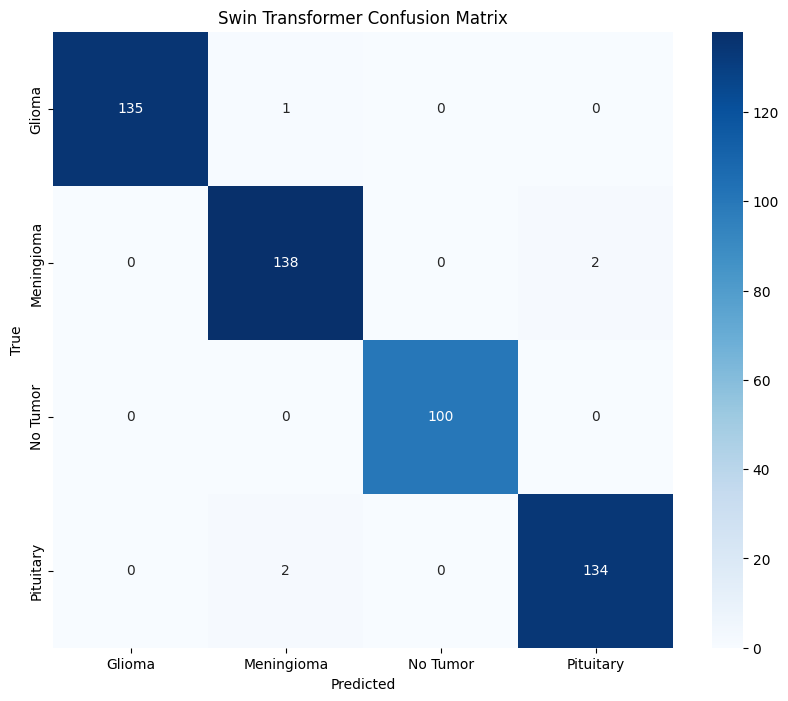

              precision    recall  f1-score   support

      Glioma       1.00      0.99      1.00       136
  Meningioma       0.98      0.99      0.98       140
    No Tumor       1.00      1.00      1.00       100
   Pituitary       0.99      0.99      0.99       136

    accuracy                           0.99       512
   macro avg       0.99      0.99      0.99       512
weighted avg       0.99      0.99      0.99       512



In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            if len(outputs.shape) > 2:
                outputs = outputs.view(outputs.size(0), -1)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=train_dataset.classes, 
                yticklabels=train_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Swin Transformer Confusion Matrix')
    plt.show()
    
    print(classification_report(y_true, y_pred, target_names=train_dataset.classes))

plot_confusion_matrix(swin_expert, val_loader)

vit 

In [20]:
import timm

# 1. BUILD ViT EXPERT
def build_vit_expert(num_classes=4):
    # 'vit_base_patch16_224' is the gold standard ViT
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
    return model.to(device)

vit_expert = build_vit_expert()

# 2. PHASE 1: FREEZE BACKBONE
for param in vit_expert.parameters():
    param.requires_grad = False
for param in vit_expert.get_classifier().parameters():
    param.requires_grad = True

# 3. OPTIMIZER & LOSS
optimizer_vit = torch.optim.AdamW(vit_expert.get_classifier().parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

print("🏗️ ViT Expert ready. Starting Phase 1...")
train_phase1(vit_expert, train_loader, val_loader, criterion, optimizer_vit, num_epochs=10)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

🏗️ ViT Expert ready. Starting Phase 1...
Epoch 1/10
----------
Train Loss: 0.5024 Acc: 0.8068
Val Loss: 0.3888 Acc: 0.8477

Epoch 2/10
----------
Train Loss: 0.2862 Acc: 0.8966
Val Loss: 0.2860 Acc: 0.8926

Epoch 3/10
----------
Train Loss: 0.2455 Acc: 0.9126
Val Loss: 0.2573 Acc: 0.9141

Epoch 4/10
----------
Train Loss: 0.2049 Acc: 0.9316
Val Loss: 0.2202 Acc: 0.9219

Epoch 5/10
----------
Train Loss: 0.1944 Acc: 0.9318
Val Loss: 0.2002 Acc: 0.9297

Epoch 6/10
----------
Train Loss: 0.1863 Acc: 0.9354
Val Loss: 0.2381 Acc: 0.9102

Epoch 7/10
----------
Train Loss: 0.1792 Acc: 0.9379
Val Loss: 0.2217 Acc: 0.9141

Epoch 8/10
----------
Train Loss: 0.1866 Acc: 0.9331
Val Loss: 0.2024 Acc: 0.9297

Epoch 9/10
----------
Train Loss: 0.1482 Acc: 0.9498
Val Loss: 0.2199 Acc: 0.9160

Epoch 10/10
----------
Train Loss: 0.1582 Acc: 0.9424
Val Loss: 0.2260 Acc: 0.9199

Training complete in 10m 2s


un freezing the vit

In [21]:
# Unfreeze the entire ViT backbone
for param in vit_expert.parameters():
    param.requires_grad = True

# Lower Learning Rate for ViT Fine-Tuning
# ViT is even more sensitive to high LRs than Swin
optimizer_vit_ft = torch.optim.AdamW(vit_expert.parameters(), lr=5e-6, weight_decay=0.01)

print("🔓 ViT Backbone Unfrozen. Starting Phase 2 (Fine-Tuning)...")

🔓 ViT Backbone Unfrozen. Starting Phase 2 (Fine-Tuning)...


running the phase 2


In [22]:
# Re-using our robust training function
train_phase1(vit_expert, train_loader, val_loader, criterion, optimizer_vit_ft, num_epochs=10)

Epoch 1/10
----------
Train Loss: 0.1125 Acc: 0.9584
Val Loss: 0.1088 Acc: 0.9648

Epoch 2/10
----------
Train Loss: 0.0567 Acc: 0.9814
Val Loss: 0.1223 Acc: 0.9551

Epoch 3/10
----------
Train Loss: 0.0344 Acc: 0.9871
Val Loss: 0.0735 Acc: 0.9844

Epoch 4/10
----------
Train Loss: 0.0317 Acc: 0.9901
Val Loss: 0.0460 Acc: 0.9883

Epoch 5/10
----------
Train Loss: 0.0120 Acc: 0.9960
Val Loss: 0.0502 Acc: 0.9863

Epoch 6/10
----------
Train Loss: 0.0124 Acc: 0.9962
Val Loss: 0.0650 Acc: 0.9844

Epoch 7/10
----------
Train Loss: 0.0134 Acc: 0.9964
Val Loss: 0.0721 Acc: 0.9883

Epoch 8/10
----------
Train Loss: 0.0075 Acc: 0.9979
Val Loss: 0.0638 Acc: 0.9766

Epoch 9/10
----------
Train Loss: 0.0122 Acc: 0.9958
Val Loss: 0.0890 Acc: 0.9844

Epoch 10/10
----------
Train Loss: 0.0098 Acc: 0.9964
Val Loss: 0.1107 Acc: 0.9902

Training complete in 27m 31s


📊 Generating Confusion Matrix for ViT Expert...


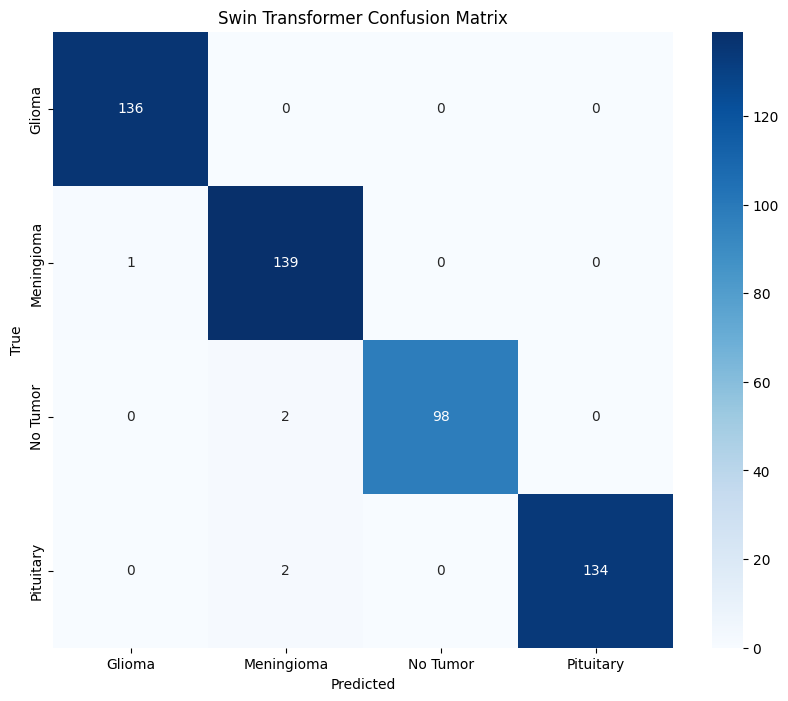

              precision    recall  f1-score   support

      Glioma       0.99      1.00      1.00       136
  Meningioma       0.97      0.99      0.98       140
    No Tumor       1.00      0.98      0.99       100
   Pituitary       1.00      0.99      0.99       136

    accuracy                           0.99       512
   macro avg       0.99      0.99      0.99       512
weighted avg       0.99      0.99      0.99       512



In [23]:
# Re-using our plotting function for the ViT model
print("📊 Generating Confusion Matrix for ViT Expert...")
plot_confusion_matrix(vit_expert, val_loader)

single image inference 


In [24]:
import PIL.Image as Image

def predict_mri(image_path, model_swin, model_vit, class_names):
    # 1. Load and Preprocess
    img = Image.open(image_path).convert('RGB')
    
    # Apply the same transforms used in validation
    img_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    # 2. Inference
    model_swin.eval()
    model_vit.eval()
    
    with torch.no_grad():
        # Swin Prediction
        out_swin = model_swin(img_tensor)
        if len(out_swin.shape) > 2: out_swin = out_swin.view(out_swin.size(0), -1)
        prob_swin = torch.nn.functional.softmax(out_swin, dim=1)
        conf_swin, pred_swin = torch.max(prob_swin, 1)
        
        # ViT Prediction
        out_vit = model_vit(img_tensor)
        if len(out_vit.shape) > 2: out_vit = out_vit.view(out_vit.size(0), -1)
        prob_vit = torch.nn.functional.softmax(out_vit, dim=1)
        conf_vit, pred_vit = torch.max(prob_vit, 1)

    # 3. Display Results
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Test Image: {os.path.basename(image_path)}")
    plt.show()
    
    print(f"{'MODEL':<15} | {'PREDICTION':<15} | {'CONFIDENCE'}")
    print("-" * 45)
    print(f"{'Swin Expert':<15} | {class_names[pred_swin]:<15} | {conf_swin.item():.2%}")
    print(f"{'ViT Expert':<15} | {class_names[pred_vit]:<15} | {conf_vit.item():.2%}")

# --- TEST IT HERE ---
# Pick an image from the Validation set
test_image = os.path.join(path, "Val/Glioma/glioma_71.jpg") # Change this path as needed
predict_mri(test_image, swin_expert, vit_expert, train_dataset.classes)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes/Val/Glioma/glioma_71.jpg'

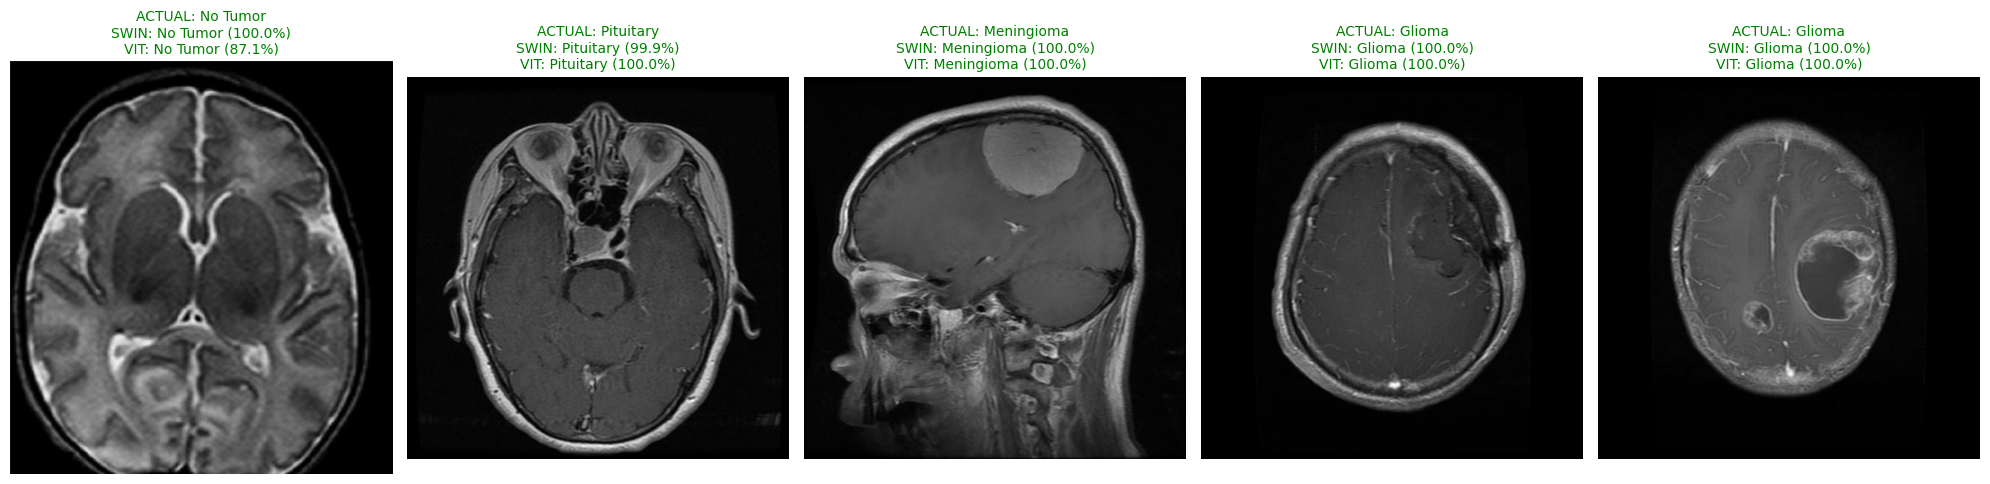

In [25]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

def test_random_samples(model_swin, model_vit, val_dataset, num_samples=5):
    class_names = val_dataset.classes
    # Get random indices
    indices = random.sample(range(len(val_dataset)), num_samples)
    
    plt.figure(figsize=(20, 10))
    
    model_swin.eval()
    model_vit.eval()
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # 1. Get image and true label
            # Note: val_dataset[idx] returns (transformed_tensor, label_int)
            image_tensor, label_idx = val_dataset[idx]
            true_name = class_names[label_idx]
            
            # 2. Get the raw image for display (without normalization)
            # We fetch the path directly from the dataset samples
            img_path, _ = val_dataset.samples[idx]
            display_img = Image.open(img_path).convert('RGB')
            
            # 3. Model Inference
            input_batch = image_tensor.unsqueeze(0).to(device)
            
            # Swin Prediction
            out_swin = model_swin(input_batch)
            if len(out_swin.shape) > 2: out_swin = out_swin.view(out_swin.size(0), -1)
            prob_swin = torch.nn.functional.softmax(out_swin, dim=1)
            conf_swin, pred_swin = torch.max(prob_swin, 1)
            
            # ViT Prediction
            out_vit = model_vit(input_batch)
            if len(out_vit.shape) > 2: out_vit = out_vit.view(out_vit.size(0), -1)
            prob_vit = torch.nn.functional.softmax(out_vit, dim=1)
            conf_vit, pred_vit = torch.max(prob_vit, 1)
            
            # 4. Plotting
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(display_img)
            
            # Color code: Green if both right, Yellow if one wrong, Red if both wrong
            color = 'green' if (pred_swin == label_idx and pred_vit == label_idx) else 'orange'
            if pred_swin != label_idx and pred_vit != label_idx: color = 'red'
            
            title = f"ACTUAL: {true_name}\n"
            title += f"SWIN: {class_names[pred_swin]} ({conf_swin.item():.1%})\n"
            title += f"VIT: {class_names[pred_vit]} ({conf_vit.item():.1%})"
            
            plt.title(title, color=color, fontsize=10)
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

# Run the test
test_random_samples(swin_expert, vit_expert, val_dataset)

In [26]:
import torch

def save_model_progress(model, model_name, class_names):
    # Create a filename with the current model name
    filename = f"{model_name}_brain_tumor_99acc.pth"
    
    # Save a dictionary containing the weights and the metadata
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'class_names': class_names,
        'model_architecture': model_name
    }
    
    torch.save(checkpoint, filename)
    print(f"💾 Saved {model_name} to: /kaggle/working/{filename}")

# Execute the save
save_model_progress(swin_expert, "Swin_Transformer", train_dataset.classes)
save_model_progress(vit_expert, "Vision_Transformer", train_dataset.classes)

💾 Saved Swin_Transformer to: /kaggle/working/Swin_Transformer_brain_tumor_99acc.pth
💾 Saved Vision_Transformer to: /kaggle/working/Vision_Transformer_brain_tumor_99acc.pth


In [27]:
import torch
import shutil
import os
from IPython.display import FileLink

# 1. Save the individual models
swin_path = "Swin_Expert_99.pth"
vit_path = "ViT_Expert_99.pth"

torch.save({
    'model_state_dict': swin_expert.state_dict(),
    'classes': train_dataset.classes,
    'arch': 'swin_tiny_patch4_window7_224'
}, swin_path)

torch.save({
    'model_state_dict': vit_expert.state_dict(),
    'classes': train_dataset.classes,
    'arch': 'vit_base_patch16_224'
}, vit_path)

# 2. Bundle them into a ZIP
# This grabs every .pth file in the working directory and zips them
zip_name = "BrainTumor_Experts_99Acc"
shutil.make_archive(zip_name, 'zip', '.', base_dir=None)

print(f"✅ Created: {zip_name}.zip")

# 3. Create a clickable download link
FileLink(f"{zip_name}.zip")

✅ Created: BrainTumor_Experts_99Acc.zip


/kaggle/working/BrainTumor_Experts_99Acc.zip